#1.Title + Objective

#Stadium Advantage Analysis in IPL

This analysis explores whether certain IPL venues favor teams batting first or second.
By comparing two eras:
- Early IPL (before 2015)
- Modern IPL (2015 onwards)

###Objective
- Identify top 10 venues by match count
- Compare defending vs chasing win ratios
- Analyze how this trend changes across eras

#2. Import Libraries

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#3.Load Dataset

In [85]:
df = pd.read_csv('matches.csv')
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [86]:
print(df.columns)

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')


#4.Data Cleaning

In [87]:
# Remove matches with no result
df = df[df['result'] != 'no result']

# Remove matches with no winner
df = df[df['winner'].notna()]


Removed no-result matches to ensure accurate analysis.

##5.Top Venues Distribution


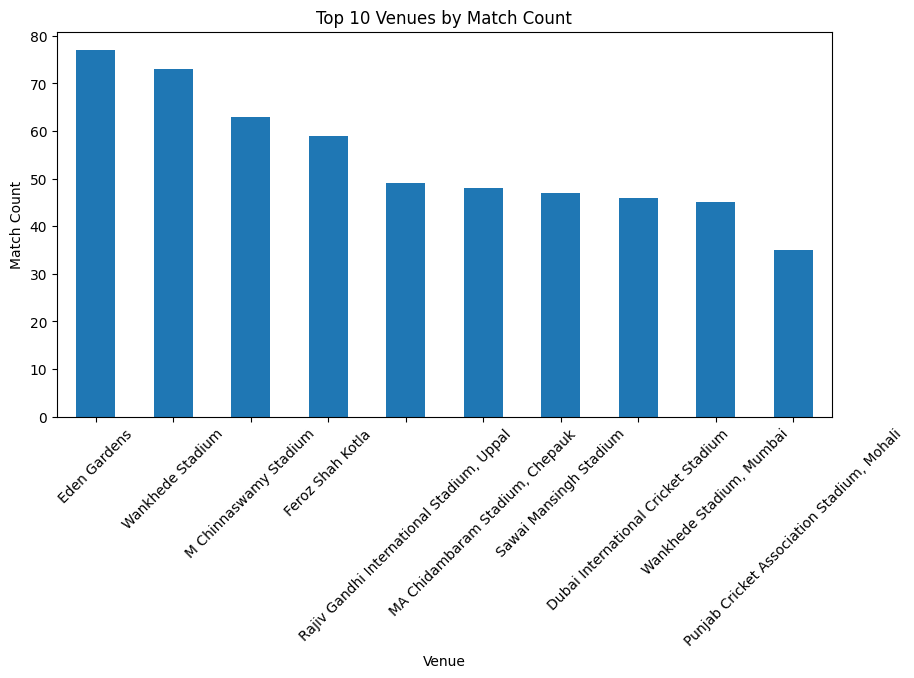

In [88]:
df['venue'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Venues by Match Count")
plt.xlabel("Venue")
plt.ylabel("Match Count")
plt.xticks(rotation=45)
plt.show()

##Graph Explanation

This bar chart shows the top 10 IPL venues based on the number of matches hosted.

- The x-axis represents different stadiums.
- The y-axis represents the total number of matches played at each venue.

This helps identify the most frequently used venues, which are selected for further analysis to ensure sufficient data for reliable insights.

In [89]:
print(df.columns)

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')


Find batting first team using toss

In [90]:
def get_batting_first_team(row):
    if row['toss_decision'] == 'bat':
        return row['toss_winner']
    else:
        return row['team1'] if row['toss_winner'] != row['team1'] else row['team2']

df['batting_first_team'] = df.apply(get_batting_first_team, axis=1)


In [91]:
def get_result_type(row):
    if row['winner'] == row['batting_first_team']:
        return 'defend'
    else:
        return 'chase'

df['result_type'] = df.apply(get_result_type, axis=1)


#6.Select Top Venues

In [92]:
top_venues = df['venue'].value_counts().head(10).index
df_top = df[df['venue'].isin(top_venues)]

Selected top 10 statiums based on the number of matches played

##7.Season Cleaning

The season column contains values like "2007/08".

Extracted only the starting year (e.g., 2007) and convert it into numeric format for analysis.

In [93]:
df['season'] = df['season'].astype(str).str[:4]
df['season'] = df['season'].astype(int)

##8.Create Era
Divide matches into two time periods:

- Early IPL -> seasons before 2015  
- Modern IPL -> seasons from 2015 onwards  

This helps compare how trends have changed over time.

In [94]:
df['era'] = df['season'].apply(lambda x: 'Early IPL' if x < 2015 else 'Modern IPL')

##9.Data Transformation (Pivot Table)
Reshape the data so that:

- Each row represents a venue and era  
- Columns show number of matches won by:
  - Defending teams  
  - Chasing teams  

This makes comparison easier.

In [95]:
top_venues = df['venue'].value_counts().head(10).index
df_top = df[df['venue'].isin(top_venues)]


In [96]:
result = df_top.groupby(['venue', 'era', 'result_type']).size().reset_index(name='count')

pivot = result.pivot_table(
index=['venue', 'era'],
columns='result_type',
values='count',
fill_value=0
)

pivot['total'] = pivot['defend'] + pivot['chase']
pivot['defend_ratio'] = pivot['defend'] / pivot['total']
pivot['chase_ratio'] = pivot['chase'] / pivot['total']

pivot = pivot.reset_index()


#10.Visualisation

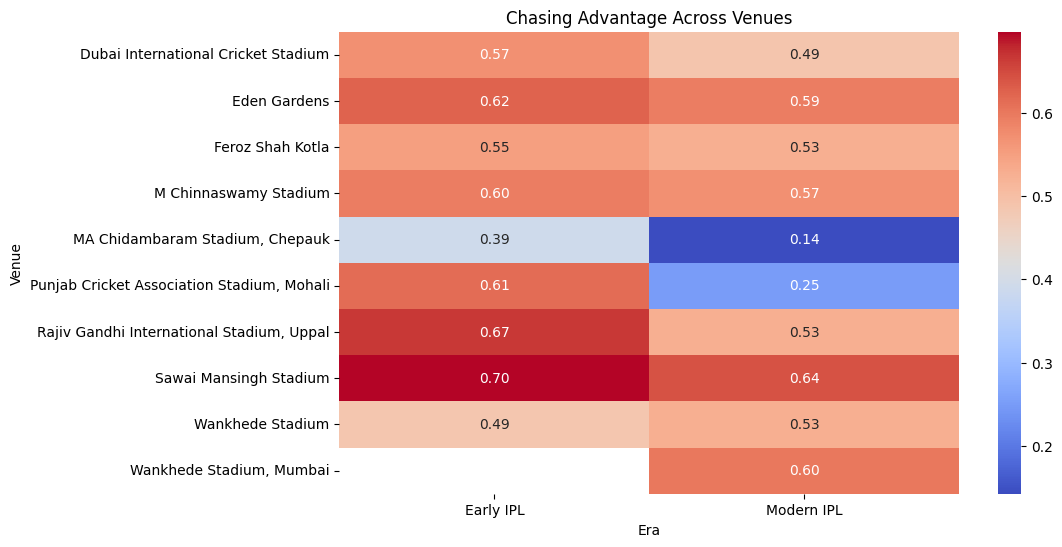

In [97]:
import seaborn as sns

heatmap_data = pivot.pivot(index='venue', columns='era', values='chase_ratio')

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Chasing Advantage Across Venues')
plt.xlabel('Era')
plt.ylabel('Venue')

plt.show()

##Chasing Advantage Heatmap

This heatmap shows the chasing win ratio across venues and eras.

- Higher values-> stronger chasing advantage  
- Lower values-> stronger defending advantage  

This visualization helps compare trends across stadiums and time periods.

###11. Insights

* Some stadiums are better for chasing, while others are better for defending.
* In recent years (modern IPL), the results have changed at some venues.

### Key Observations

* **Sawai Mansingh Stadium** is good for chasing in both early and modern IPL.
* **Eden Gardens** and **M Chinnaswamy Stadium** also support chasing.
* **MA Chidambaram Stadium (Chepauk)** is very strong for defending, especially in modern IPL.
* **Punjab Cricket Association Stadium, Mohali** has changed a lot — earlier it supported chasing, but now it supports defending.
* **Wankhede Stadium** shows better chasing results in modern IPL.

### Final Takeaways

* **Best stadium to chase:** Sawai Mansingh Stadium
* **Best stadium to defend:** MA Chidambaram Stadium (Chepauk)
